In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve
)

from xgboost import XGBClassifier


In [2]:
# 1. CARGAR DATOS
# =========================================================
df = pd.read_csv("natalidad_preprocesado_ucin.csv")

target = "ucin"
X = df.drop(columns=[target])
y = df[target]

In [3]:
# 2. TRAIN / TEST
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [4]:
# 3. CALCULAR DESBALANCE
# =========================================================
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 9.538309636650869


In [5]:
#4. MODELO FINAL XGBOOST

xgb_model = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    min_child_weight=3,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

In [6]:
# 5. ENTRENAR
# =========================================================
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [7]:
# =========================================================
# 6. BÚSQUEDA DEL MEJOR UMBRAL SEGÚN RECALL OBJETIVO
# =========================================================

import numpy as np
import pandas as pd

# Recall clínico objetivo
recall_objetivo = 0.80

# Probabilidades de clase positiva (UCIN = 1)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Probar múltiples umbrales
umbrales = np.arange(0.10, 0.91, 0.01)

resultados_umbral = []

for umbral in umbrales:

    y_pred = (y_proba >= umbral).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    resultados_umbral.append({
        "umbral": umbral,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "diferencia_recall": abs(recall - recall_objetivo)
    })

# Convertir resultados a DataFrame
df_umbral = pd.DataFrame(resultados_umbral)

# Elegir umbral más cercano al recall objetivo
mejor_umbral = df_umbral.sort_values(
    by=["diferencia_recall", "f1_score"],
    ascending=[True, False]
).iloc[0]

print("================= MEJOR UMBRAL XGBOOST =================")
print(f"Recall objetivo : {recall_objetivo:.2f}")
print(f"Umbral elegido  : {mejor_umbral['umbral']:.2f}")
print(f"Accuracy        : {mejor_umbral['accuracy']:.4f}")
print(f"Precision       : {mejor_umbral['precision']:.4f}")
print(f"Recall          : {mejor_umbral['recall']:.4f}")
print(f"F1-score        : {mejor_umbral['f1_score']:.4f}")

print("\nTop 10 umbrales más cercanos al recall objetivo:")
print(df_umbral.sort_values(by="diferencia_recall").head(10))

================= MEJOR UMBRAL XGBOOST =================
Recall objetivo : 0.80
Umbral elegido  : 0.47
Accuracy        : 0.8672
Precision       : 0.4002
Recall          : 0.8010
F1-score        : 0.5337

Top 10 umbrales más cercanos al recall objetivo:
    umbral  accuracy  precision    recall  f1_score  diferencia_recall
37    0.47  0.867203   0.400211  0.801020  0.533747           0.001020
38    0.48  0.870954   0.407901  0.797056  0.539637           0.002944
36    0.46  0.863319   0.392629  0.805185  0.527859           0.005185
39    0.49  0.874502   0.415500  0.792977  0.545285           0.007023
35    0.45  0.859258   0.385080  0.809536  0.521902           0.009536
40    0.50  0.877975   0.423264  0.788597  0.550863           0.011403
34    0.44  0.855181   0.377843  0.813715  0.516058           0.013715
41    0.51  0.881346   0.431179  0.784432  0.556478           0.015568
33    0.43  0.851128   0.370945  0.817550  0.510337           0.017550
42    0.52  0.884556   0.439036  0.77

In [8]:
# 7. PROBABILIDADES
# =========================================================
y_proba = xgb_model.predict_proba(X_test)[:, 1]


In [11]:
# 8. UMBRAL FINAL
# =========================================================
umbral = 0.43
y_pred = (y_proba >= umbral).astype(int)


================= MÉTRICAS XGBOOST FINAL =================
Umbral   : 0.43
Accuracy : 0.8511
Precision: 0.3709
Recall   : 0.8175
F1-score : 0.5103
AUC-ROC  : 0.9064

================= CLASSIFICATION REPORT =================
              precision    recall  f1-score   support

           0     0.9781    0.8546    0.9122    664153
           1     0.3709    0.8175    0.5103     69630

    accuracy                         0.8511    733783
   macro avg     0.6745    0.8361    0.7113    733783
weighted avg     0.9205    0.8511    0.8741    733783



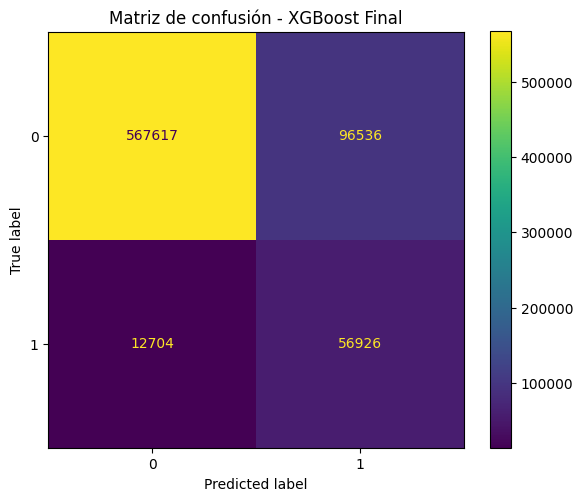

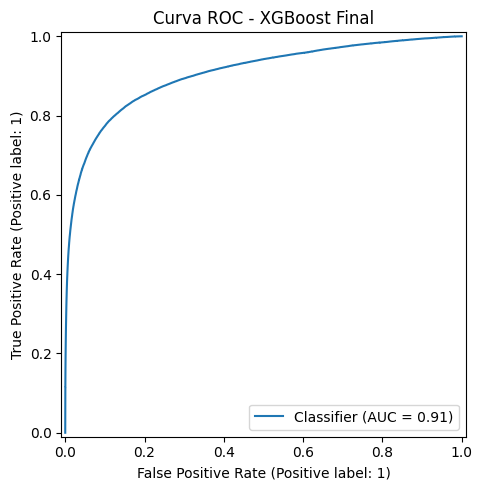

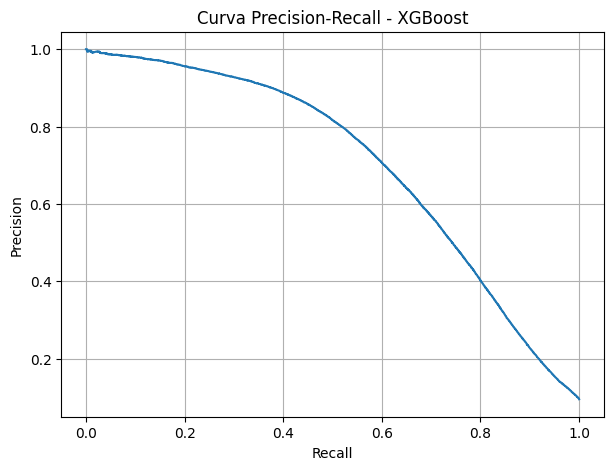


================= TOP 15 VARIABLES MÁS IMPORTANTES =================
    Variable  Importancia
56  ab_aven1     0.240830
54  combgest     0.152054
55      dbwt     0.107218
57  ab_aven6     0.061437
40   ld_chor     0.050564
38   ld_ster     0.047167
43   me_rout     0.046799
51    apgar5     0.044877
23  rf_pdiab     0.025091
61   ca_cchd     0.024170
35   ip_hepc     0.016294
32   ip_syph     0.015974
41   ld_anes     0.010012
39   ld_antb     0.009585
26  rf_ghype     0.008522


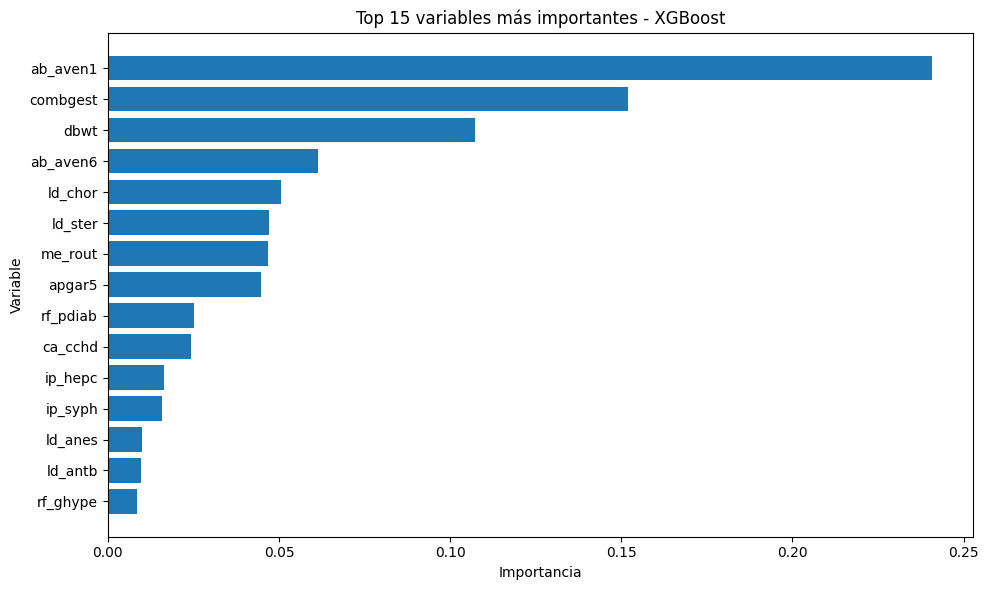

In [13]:

# 9. MÉTRICAS
# =========================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("\n================= MÉTRICAS XGBOOST FINAL =================")
print(f"Umbral   : {umbral:.2f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

print("\n================= CLASSIFICATION REPORT =================")
print(classification_report(y_test, y_pred, digits=4))

# =========================================================
# 10. MATRIZ DE CONFUSIÓN
# =========================================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(values_format="d", ax=ax)
ax.set_title("Matriz de confusión - XGBoost Final")
plt.tight_layout()
plt.show()

# =========================================================
# 11. CURVA ROC
# =========================================================
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
ax.set_title("Curva ROC - XGBoost Final")
plt.tight_layout()
plt.show()

# =========================================================
# 12. CURVA PRECISION-RECALL
# =========================================================
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - XGBoost")
plt.grid(True)
plt.show()

# =========================================================
# 13. IMPORTANCIA DE VARIABLES
# =========================================================
importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": xgb_model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print("\n================= TOP 15 VARIABLES MÁS IMPORTANTES =================")
print(importance_df.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Variable"].head(15)[::-1],
    importance_df["Importancia"].head(15)[::-1]
)
plt.title("Top 15 variables más importantes - XGBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# =========================================================
# 14. GUARDAR RESULTADOS
# =========================================================
importance_df.to_csv("importancia_variables_xgboost.csv", index=False)

resultados = X_test.copy()
resultados["y_real"] = y_test.values
resultados["y_pred"] = y_pred
resultados["prob_ucin"] = y_proba

resultados.to_csv("predicciones_xgboost.csv", index=False)